## SECTION 1 — Setup & Load Data

**Why:** Before anything else we need to confirm the libraries work and the dataset loads correctly.

**What we learn:** Shape of the data (rows × columns), column names.

In [1]:
# Cell 1 — Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [2]:
# Cell 2 — Load the dataset
df = pd.read_csv('../data/skill_builder_data.csv',
                 encoding='ISO-8859-1',
                 low_memory=False)

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

Shape: (525534, 30)
Columns: ['order_id', 'assignment_id', 'user_id', 'assistment_id', 'problem_id', 'original', 'correct', 'attempt_count', 'ms_first_response', 'tutor_mode', 'answer_type', 'sequence_id', 'student_class_id', 'position', 'type', 'base_sequence_id', 'skill_id', 'skill_name', 'teacher_id', 'school_id', 'hint_count', 'hint_total', 'overlap_time', 'template_id', 'answer_id', 'answer_text', 'first_action', 'bottom_hint', 'opportunity', 'opportunity_original']


## SECTION 2 — Missing Values Analysis

**Why:** BKT needs a clean sequence of correct/incorrect answers per student per skill. Any row without a skill label is useless for our model and must be dropped.

**What to look for:**
- skill_name: ~15% missing — these rows MUST be dropped
- bottom_hint: ~85% missing — normal, most students don't use all hints
- correct, user_id, opportunity: should be 0% missing

In [3]:
# Cell 3 — Check missing values in key columns
key_cols = ['user_id', 'skill_name', 'correct', 'opportunity',
            'hint_count', 'bottom_hint', 'original']

print("Missing values in key columns:")
for col in key_cols:
    missing = df[col].isna().sum()
    pct = round(missing / len(df) * 100, 1)
    print(f"  {col}: {missing} missing ({pct}%)")

Missing values in key columns:
  user_id: 0 missing (0.0%)
  skill_name: 78690 missing (15.0%)
  correct: 0 missing (0.0%)
  opportunity: 0 missing (0.0%)
  hint_count: 0 missing (0.0%)
  bottom_hint: 445627 missing (84.8%)
  original: 0 missing (0.0%)


## SECTION 3 — Original vs Scaffold Rows

**Why:** The ASSISTments platform breaks some problems into smaller "scaffold" steps. These are NOT real problem attempts — including them would distort mastery estimates.

- `original = 1` → real problem attempt ✅ keep
- `original = 0` → scaffold/hint step ❌ remove

In [4]:
# Cell 4 — Inspect the original column
print("Value counts for 'original' column:")
print(df['original'].value_counts())

print("\noriginal=1 (real problems):", len(df[df['original'] == 1]))
print("original=0 (scaffold steps):", len(df[df['original'] == 0]))

Value counts for 'original' column:
original
1    449220
0     76314
Name: count, dtype: int64

original=1 (real problems): 449220
original=0 (scaffold steps): 76314


## SECTION 4 — Duplicate Rows

**Why:** The original (uncorrected) version of this dataset had known duplicate rows. We verify this as a quality check.

In [5]:
# Cell 5 — Check for duplicates
print("Total duplicate rows:", df.duplicated().sum())

Total duplicate rows: 0


## SECTION 5 — Student & Skill Statistics

**Why:** We need to understand the scale of the dataset and whether students have enough interactions per skill for BKT to work meaningfully.

**What to look for:** Ideally median > 50 interactions per student.

In [6]:
# Cell 6 — Basic dataset statistics
print("Total students:", df['user_id'].nunique())
print("Total skills:", df['skill_name'].nunique())
print("Total interactions:", len(df))
print("\nOverall correct rate:", round(df['correct'].mean() * 100, 1), "%")

print("\nTop 5 most practiced skills:")
print(df['skill_name'].value_counts().head())

Total students: 4217
Total skills: 110
Total interactions: 525534

Overall correct rate: 67.9 %

Top 5 most practiced skills:
skill_name
Equation Solving Two or Fewer Steps         24253
Percent Of                                  22931
Addition and Subtraction Integers           22895
Conversion of Fraction Decimals Percents    20992
Volume Rectangular Prism                    19489
Name: count, dtype: int64


Interactions per student:
  Mean: 124.6
  Median: 27.0
  Min: 1
  Max: 8214


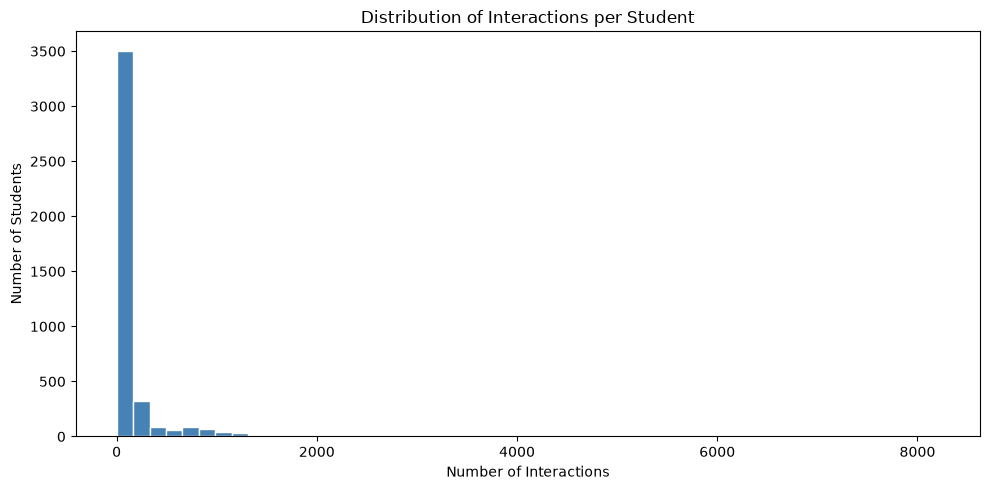

In [7]:
# Cell 7 — How many interactions does each student have?
interactions_per_student = df.groupby('user_id').size()

print("Interactions per student:")
print("  Mean:", round(interactions_per_student.mean(), 1))
print("  Median:", round(interactions_per_student.median(), 1))
print("  Min:", interactions_per_student.min())
print("  Max:", interactions_per_student.max())

plt.figure(figsize=(10, 5))
plt.hist(interactions_per_student, bins=50, color='steelblue', edgecolor='white')
plt.title('Distribution of Interactions per Student')
plt.xlabel('Number of Interactions')
plt.ylabel('Number of Students')
plt.tight_layout()
plt.savefig('../outputs/figures/interactions_per_student.png', dpi=150)
plt.show()

## SECTION 6 — Skill Distribution

**Why:** We need to know which skills have enough data to model reliably. Skills with very few responses (e.g. < 100 total) should be excluded from BKT training.

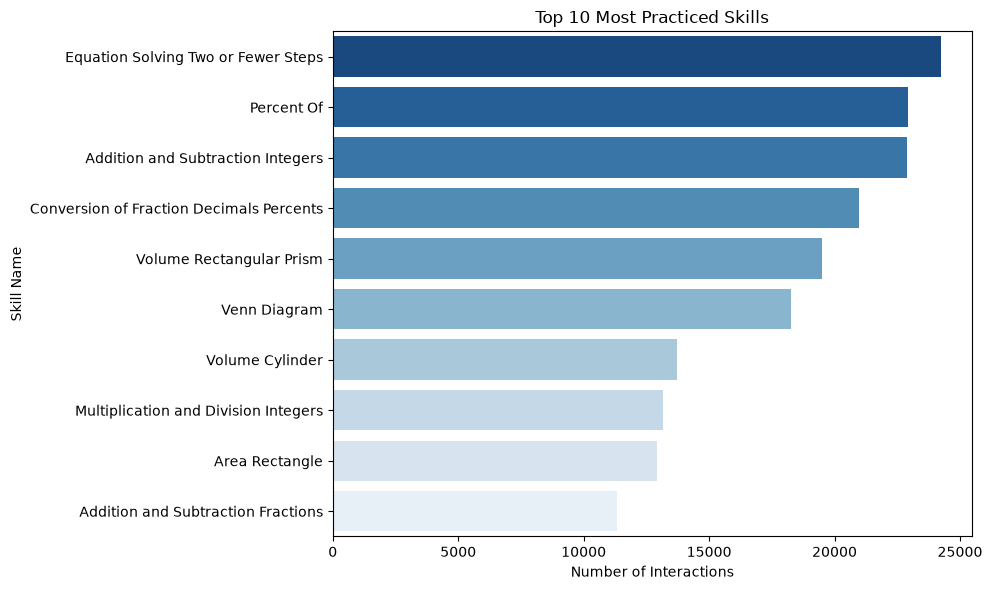

In [8]:
# Cell 8 — Top 10 skills by number of interactions
top_skills = df['skill_name'].value_counts().head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_skills.values, y=top_skills.index, hue=top_skills.index, palette='Blues_r', legend=False)
plt.title('Top 10 Most Practiced Skills')
plt.xlabel('Number of Interactions')
plt.ylabel('Skill Name')
plt.tight_layout()
plt.savefig('../outputs/figures/top_skills.png', dpi=150)
plt.show()

In [9]:
# Cell 9 — How many skills have fewer than 100 total interactions?
skill_counts = df['skill_name'].value_counts()
rare_skills = skill_counts[skill_counts < 100]
print(f"Skills with fewer than 100 interactions: {len(rare_skills)} out of {len(skill_counts)}")
print("\nRarest skills:")
print(rare_skills.tail(10))

Skills with fewer than 100 interactions: 15 out of 110

Rarest skills:
skill_name
Slope                                            89
Percent Discount                                 47
Computation with Real Numbers                    42
Interpreting Coordinate Graphs                   33
Midpoint                                         32
Quadratic Formula to Solve Quadratic Equation    32
Distributive Property                            18
Finding Slope From Situation                      9
Reading a Ruler or Scale                          5
Finding Slope from Ordered Pairs                  5
Name: count, dtype: int64


## SECTION 7 — The Learning Signal (Most Important Chart)

**Why:** BKT assumes that as students practice a skill more times, their probability of answering correctly increases. If we don't see this pattern, BKT is not appropriate.

**What we expect:** Correct rate should generally increase as opportunity number increases.

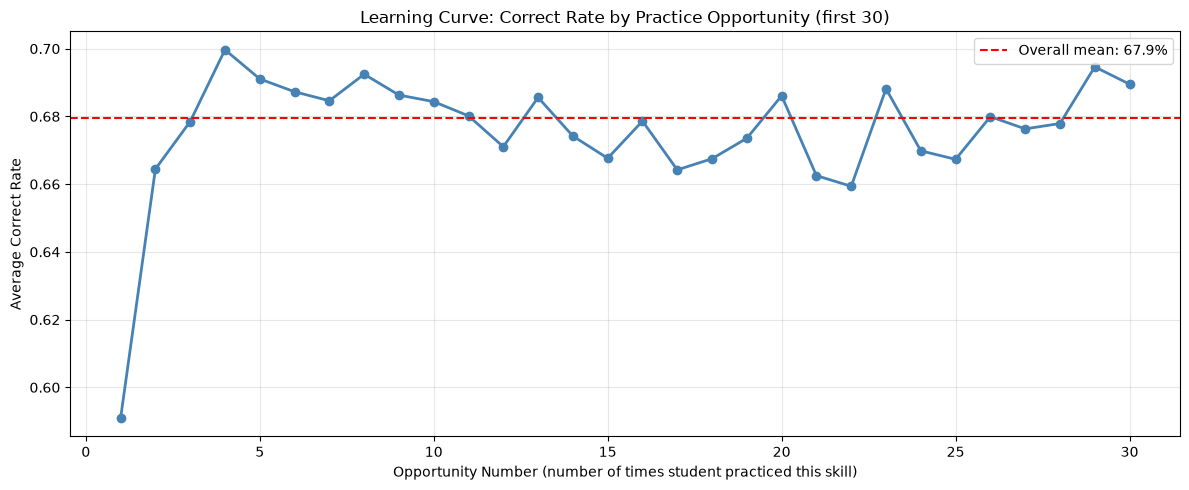

In [10]:
# Cell 10 — Correct rate by opportunity number (learning curve)
opp_correct = df[df['skill_name'].notna()].groupby('opportunity')['correct'].mean()

plt.figure(figsize=(12, 5))
plt.plot(opp_correct.index[:30], opp_correct.values[:30],
         marker='o', color='steelblue', linewidth=2)
plt.title('Learning Curve: Correct Rate by Practice Opportunity (first 30)')
plt.xlabel('Opportunity Number (number of times student practiced this skill)')
plt.ylabel('Average Correct Rate')
plt.axhline(y=df['correct'].mean(), color='red', linestyle='--',
            label=f'Overall mean: {round(df["correct"].mean()*100,1)}%')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../outputs/figures/learning_curve.png', dpi=150)
plt.show()

## SECTION 8 — Hint Usage Analysis

**Why:** Hint usage is an indicator of student difficulty. A student who answers correctly after many hints is different from one who answers correctly on the first attempt.

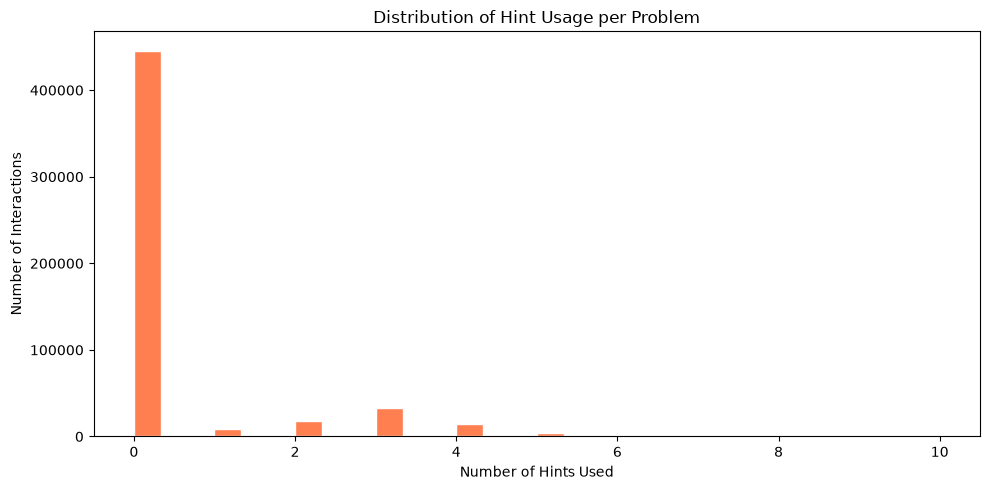

Problems with 0 hints: 445631
Problems with 1+ hints: 79903
Average hints per problem: 0.44


In [11]:
# Cell 11 — Hint usage distribution
plt.figure(figsize=(10, 5))
plt.hist(df['hint_count'], bins=30, color='coral', edgecolor='white')
plt.title('Distribution of Hint Usage per Problem')
plt.xlabel('Number of Hints Used')
plt.ylabel('Number of Interactions')
plt.tight_layout()
plt.savefig('../outputs/figures/hint_distribution.png', dpi=150)
plt.show()

print("Problems with 0 hints:", (df['hint_count'] == 0).sum())
print("Problems with 1+ hints:", (df['hint_count'] > 0).sum())
print("Average hints per problem:", round(df['hint_count'].mean(), 2))

## SECTION 9 — Summary Table (for Thesis)

**Why:** Produces a clean summary of all key dataset statistics to copy directly into the Methodology chapter.

In [12]:
# Cell 12 — Summary statistics table
summary = {
    'Total interactions': len(df),
    'Total students': df['user_id'].nunique(),
    'Total skills': df['skill_name'].nunique(),
    'Overall correct rate (%)': round(df['correct'].mean() * 100, 1),
    'Avg interactions per student': round(df.groupby('user_id').size().mean(), 1),
    'Median interactions per student': round(df.groupby('user_id').size().median(), 1),
    'Rows missing skill_name (%)': round(df['skill_name'].isna().mean() * 100, 1),
    'Scaffold rows (original=0) (%)': round((df['original'] == 0).mean() * 100, 1),
    'Avg hints per problem': round(df['hint_count'].mean(), 2),
}

print("=== DATASET SUMMARY (copy to thesis) ===")
for key, val in summary.items():
    print(f"  {key}: {val}")

=== DATASET SUMMARY (copy to thesis) ===
  Total interactions: 525534
  Total students: 4217
  Total skills: 110
  Overall correct rate (%): 67.9
  Avg interactions per student: 124.6
  Median interactions per student: 27.0
  Rows missing skill_name (%): 15.0
  Scaffold rows (original=0) (%): 14.5
  Avg hints per problem: 0.44
